# 🏥 Indian Medicine Dataset: An Exploratory Data Story

### Uncovering Patterns in Pharmaceutical Manufacturers, Affordability, Active Ingredients, and Formulation Dynamics

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-blue?style=for-the-badge&logo=googlecolab)](https://colab.research.google.com/github/chrisharris1/CDS-CIA-2-Indian-Medicine-Data-Story/blob/main/Indian_Medicine_DataStory.ipynb)

---

**Group Assignment Deliverable — CIA 2**  
* **Dataset Topic**: Healthcare and Lifestyle (Pharmaceutical Medicine Catalogue of India)
* **Visualisation Framework**: Plotly Only (Interactive Visualizations)
* **Objective**: Use Python to clean, analyze, and explore real-world pharmaceutical records, uncover 5 evidence-backed healthcare insights, and communicate findings through a cohesive data story.


## 1. Introduction

India is globally recognized as the *"Pharmacy of the World"*, serving as one of the largest producers and consumers of generic and branded medications. The Indian pharmaceutical marketplace contains a diverse ecosystem of manufacturers, pricing structures, and chemical formulations spanning acute and chronic therapies.

In this project, we analyze a comprehensive dataset containing over **250,000 medicine records** from across India to investigate fundamental questions:
1. **Catalogue Concentration**: How concentrated are medicine listings among industry leaders versus smaller regional producers?
2. **Pricing & Affordability**: How are medicine prices distributed across the country, and what share of treatments are accessible at low cost?
3. **Manufacturer Price Distributions**: Do leading pharmaceutical manufacturers exhibit uniform pricing, or do their catalogue spreads reflect distinct price distributions?
4. **Formulated Chemical Ingredients**: Which active pharmaceutical ingredients (APIs) are most frequently represented across the catalogue?
5. **Formulation Architecture**: How prevalent are combination formulations compared to single-ingredient medications?

### The Data Story Philosophy
Rather than jumping straight to modeling, this project follows an evidence-based storytelling methodology:
$$\text{Raw Ingestion (253,973)} \longrightarrow \text{Data Governance \& Scope Validation} \longrightarrow \text{Clean Analytical Dataset (243,803)} \longrightarrow \text{5 Core Insights} \longrightarrow \text{Interactive Plotly Visuals} \longrightarrow \text{Synthesis}$$


## 2. Dataset Overview and Schema

### Source
* **Dataset**: *A-Z Medicine Dataset of India* (Publicly available on Kaggle)
* **Ingestion Size**: 253,973 records across 9 attributes

### Core Variables

| Variable Name | Data Type | Description & Role |
| :--- | :--- | :--- |
| `id` | Integer | Unique identifier for each pharmaceutical record |
| `name` | String | Commercial brand name of the medicine |
| `price(₹)` | Float | Maximum Retail Price (MRP) in Indian Rupees (INR ₹) |
| `Is_discontinued` | Boolean | Flag indicating whether the drug is discontinued or active |
| `manufacturer_name` | String | Pharmaceutical company producing the medicine |
| `type` | String | Medicine classification system (e.g., Allopathy) |
| `pack_size_label` | String | Packaging form (strip, bottle, vial, box) and unit quantity |
| `short_composition1` | String | Primary active chemical ingredient and dosage strength |
| `short_composition2` | String | Secondary active chemical ingredient (for combination formulations) |


## 3. Environment Setup and Data Ingestion

We load the required Python libraries for data manipulation and visualization. In strict accordance with project guidelines, **Plotly Express** and **Plotly Graph Objects** are used exclusively for all charts.


In [1]:
!pip install -q kaleido==0.2.1
import importlib
import plotly.io._kaleido
try:
    importlib.reload(plotly.io._kaleido)
except Exception:
    pass

import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Try importing display for rich notebook outputs
try:
    from IPython.display import display
except ImportError:
    display = print

# Configure Plotly renderer
pio.templates.default = "plotly_white"
pio.renderers.default = "colab+png"

# 1. Automatically mount Google Drive if running on Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # Running locally on PC

# 2. Resilient data path lookup
possible_paths = [
    Path('/content/drive/MyDrive/Colab Notebooks/A_Z_medicines_dataset_of_India.csv'),
    Path('/content/drive/MyDrive/A_Z_medicines_dataset_of_India.csv'),
    Path('/content/A_Z_medicines_dataset_of_India.csv'),
    Path('../data/raw_indian_medicines/A_Z_medicines_dataset_of_India.csv'),
    Path('../ai-models/data/raw_indian_medicines/A_Z_medicines_dataset_of_India.csv'),
    Path('ai-models/data/raw_indian_medicines/A_Z_medicines_dataset_of_India.csv'),
    Path('data/raw_indian_medicines/A_Z_medicines_dataset_of_India.csv'),
    Path('A_Z_medicines_dataset_of_India.csv'),
]

data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find A_Z_medicines_dataset_of_India.csv in expected directories.')

df_raw = pd.read_csv(data_path)
print(f'[OK] Successfully ingested raw dataset from: {data_path}')
print(f'[INFO] Initial Dimensions: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')


Mounted at /content/drive
[OK] Successfully ingested raw dataset from: /content/drive/MyDrive/Colab Notebooks/A_Z_medicines_dataset_of_India.csv
[INFO] Initial Dimensions: 253,973 rows × 9 columns


In [2]:
# Display preview of initial raw records
df_raw.head()


,id,name,price(₹),Is_discontinued,manufacturer_name,type,pack_size_label,short_composition1,short_composition2
0,1,Augmentin 625 Duo Tablet,223.42,False,Glaxo SmithKline Pharmaceuticals Ltd,allopathy,strip of 10 tablets,Amoxycillin (500mg),Clavulanic Acid (125mg)
1,2,Azithral 500 Tablet,132.36,False,Alembic Pharmaceuticals Ltd,allopathy,strip of 5 tablets,Azithromycin (500mg),NaN
2,3,Ascoril LS Syrup,118.00,False,Glenmark Pharmaceuticals Ltd,allopathy,bottle of 100 ml Syrup,Ambroxol (30mg/5ml),Levosalbutamol (1mg/5ml)
3,4,Allegra 120mg Tablet,218.81,False,Sanofi India Ltd,allopathy,strip of 10 tablets,Fexofenadine (120mg),NaN
4,5,Avil 25 Tablet,10.96,False,Sanofi India Ltd,allopathy,strip of 15 tablets,Pheniramine (25mg),NaN


## 4. Raw Data Quality Audit

Before performing any transformations, we inspect the data schema, column types, missing values, duplicates, and initial summary statistics.


In [3]:
# Column list and data types
print("--- Column Information & Data Types ---")
df_raw.info()


--- Column Information & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253973 entries, 0 to 253972
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  253973 non-null  int64  
 1   name                253973 non-null  object 
 2   price(₹)            253973 non-null  float64
 3   Is_discontinued     253973 non-null  bool   
 4   manufacturer_name   253973 non-null  object 
 5   type                253973 non-null  object 
 6   pack_size_label     253973 non-null  object 
 7   short_composition1  253973 non-null  object 
 8   short_composition2  112171 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 15.7+ MB


In [4]:
# Audit missing values per column
missing_audit = pd.DataFrame({
    "Missing Count": df_raw.isnull().sum(),
    "Missing Percentage (%)": (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
missing_audit.sort_values(by="Missing Count", ascending=False)


,Missing Count,Missing Percentage (%)
short_composition2,141802,55.83
id,0,0.00
name,0,0.00
Is_discontinued,0,0.00
price(₹),0,0.00
manufacturer_name,0,0.00
type,0,0.00
pack_size_label,0,0.00
short_composition1,0,0.00


In [5]:
# Check for exact duplicate rows
duplicate_count = df_raw.duplicated().sum()
print(f"Exact Duplicate Records: {duplicate_count:,}")


Exact Duplicate Records: 0


In [6]:
# Initial numerical distribution summary
df_raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,253973.0,NaN,NaN,NaN,126987.0,73315.834296,1.0,63494.0,126987.0,190480.0,253973.0
name,253973,249398,NS 0.9% Infusion,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price(₹),253973.0,NaN,NaN,NaN,270.530844,3029.584134,0.0,48.0,79.0,140.0,436000.0
Is_discontinued,253973,2,False,246068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manufacturer_name,253973,7648,Sun Pharmaceutical Industries Ltd,2986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,253973,1,allopathy,253973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pack_size_label,253973,1929,strip of 10 tablets,116540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
short_composition1,253973,8523,Aceclofenac (100mg),6930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
short_composition2,112171,2980,Rabeprazole (20mg),4743,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observations from Raw Data Audit
1. **Completeness**: Core fields (`name`, `price(₹)`, `manufacturer_name`, `short_composition1`, `type`) contain **0 missing values**.
2. **Secondary Composition**: `short_composition2` is absent in 141,802 rows (55.83%), indicating single-ingredient medicines rather than missing data.
3. **Discontinued Records**: 7,905 medicines are flagged as discontinued (`Is_discontinued == True`).
4. **Outliers / Boundary Values**: Minimum price in raw data is ₹0.00 and extreme upper values require boundary filtering.


## 5. Step-by-Step Data Cleaning Pipeline

To ensure rigorous data governance, we apply cleaning filters sequentially. Each step logs before/after record counts.

> **Methodological Note**: We intentionally avoid restricting the dataset to an arbitrary list of manufacturers or filtering down to the "5,000 cheapest" records. Analyzing the full clean catalogue ensures our statistical insights remain unbiased and representative of the actual catalogue.


In [7]:
# Initialize clean dataframe
df_clean = df_raw.copy()
cleaning_audit_log = []

# --- Step 5.1: Remove Discontinued Medicines ---
before_count = len(df_clean)
df_clean = df_clean[df_clean["Is_discontinued"] == False].copy()
after_count = len(df_clean)
removed = before_count - after_count

cleaning_audit_log.append({
    "Stage": "1. Remove Discontinued Medicines",
    "Condition": "Is_discontinued == False",
    "Before": before_count,
    "After": after_count,
    "Removed": removed,
    "Retention (%)": round(after_count / len(df_raw) * 100, 2)
})

print(f"Step 5.1 Completed: Removed {removed:,} discontinued drugs | Retained {after_count:,}")


Step 5.1 Completed: Removed 7,905 discontinued drugs | Retained 246,068


In [8]:
# --- Step 5.2: Price Boundary Cleaning ---
# Filter out non-commercial / erroneous prices (<= ₹1.00) and extreme outliers (>= ₹3,000.00)
before_count = len(df_clean)
price_col = "price(₹)"
df_clean = df_clean[(df_clean[price_col] > 1.0) & (df_clean[price_col] < 3000.0)].copy()
after_count = len(df_clean)
removed = before_count - after_count

cleaning_audit_log.append({
    "Stage": "2. Price Boundary Validation",
    "Condition": "₹1.00 < Price < ₹3,000.00",
    "Before": before_count,
    "After": after_count,
    "Removed": removed,
    "Retention (%)": round(after_count / len(df_raw) * 100, 2)
})

print(f"Step 5.2 Completed: Removed {removed:,} price outlier records | Retained {after_count:,}")


Step 5.2 Completed: Removed 2,265 price outlier records | Retained 243,803


In [9]:
# --- Step 5.3: Scope Verification (Allopathy Only) ---
# Scope check: verify that all entries in the dataset conform to allopathic classification
before_count = len(df_clean)
df_clean = df_clean[df_clean["type"].astype(str).str.lower() == "allopathy"].copy()
after_count = len(df_clean)
removed = before_count - after_count

cleaning_audit_log.append({
    "Stage": "3. Scope Check (Allopathy Only)",
    "Condition": "type.lower() == 'allopathy'",
    "Before": before_count,
    "After": after_count,
    "Removed": removed,
    "Retention (%)": round(after_count / len(df_raw) * 100, 2)
})

print(f"Step 5.3 Completed: Scope check confirmed all {after_count:,} records are allopathic ({removed} removed for category mismatch)")


Step 5.3 Completed: Scope check confirmed all 243,803 records are allopathic (0 removed for category mismatch)


In [10]:
# --- Step 5.4: Drop Duplicates and Reset Index ---
before_count = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after_count = len(df_clean)
removed = before_count - after_count

cleaning_audit_log.append({
    "Stage": "4. Duplicate De-duplication",
    "Condition": "drop_duplicates()",
    "Before": before_count,
    "After": after_count,
    "Removed": removed,
    "Retention (%)": round(after_count / len(df_raw) * 100, 2)
})

print(f"Step 5.4 Completed: Deduplication finished | Final Clean Records: {after_count:,}")


Step 5.4 Completed: Deduplication finished | Final Clean Records: 243,803


## 6. Cleaning Results Summary

A structured breakdown of data retention across each cleaning stage, accompanied by an interactive Plotly Funnel Visualization.


In [11]:
# Display audit table
audit_df = pd.DataFrame(cleaning_audit_log)
audit_df


,Stage,Condition,Before,After,Removed,Retention (%)
0,1. Remove Discontinued Medicines,Is_discontinued == False,253973,246068,7905,96.89
1,2. Price Boundary Validation,"₹1.00 < Price < ₹3,000.00",246068,243803,2265,96.00
2,3. Scope Check (Allopathy Only),type.lower() == 'allopathy',243803,243803,0,96.00
3,4. Duplicate De-duplication,drop_duplicates(),243803,243803,0,96.00


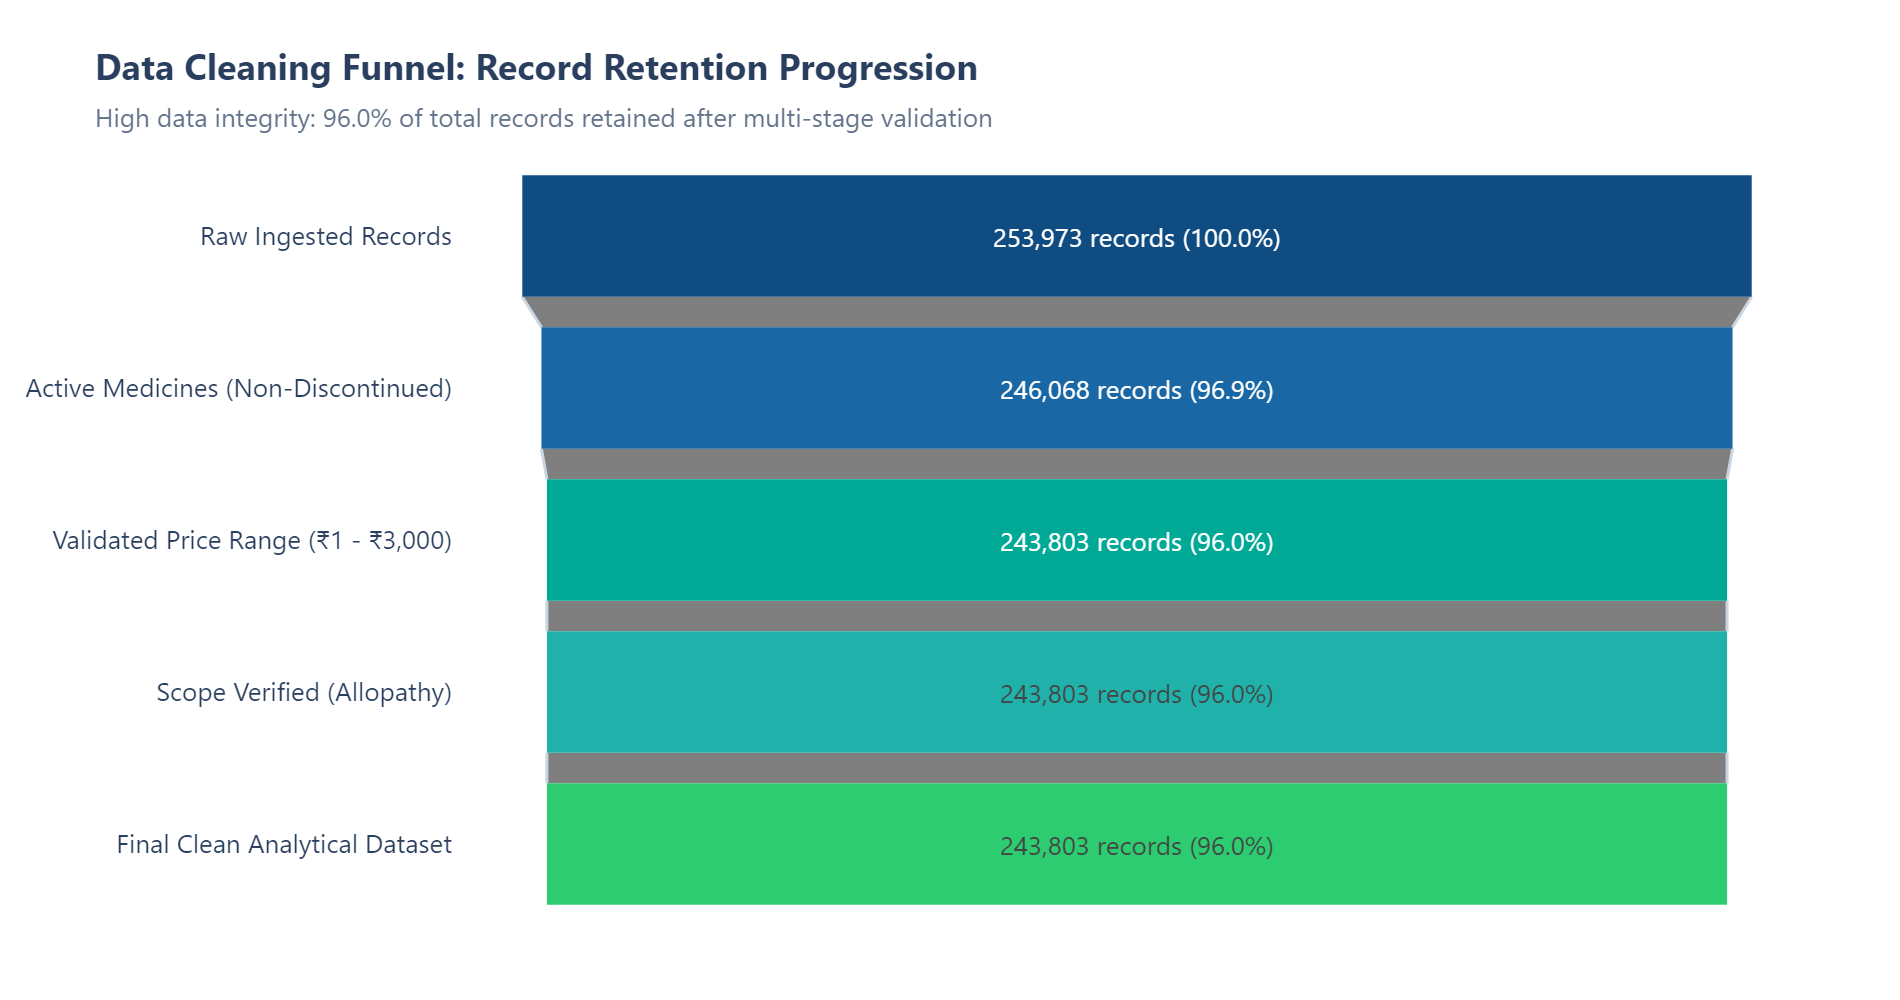

In [12]:
# Plotly Funnel Chart: Data Retention Pipeline
funnel_stages = [
    "Raw Ingested Records",
    "Active Medicines (Non-Discontinued)",
    "Validated Price Range (₹1 - ₹3,000)",
    "Scope Verified (Allopathy)",
    "Final Clean Analytical Dataset"
]
funnel_counts = [len(df_raw)] + audit_df["After"].tolist()

fig_funnel = go.Figure(
    go.Funnel(
        y=funnel_stages,
        x=funnel_counts,
        textposition="inside",
        textinfo="value+percent initial",
        texttemplate="%{value:,.0f} records (%{percentInitial:.1%})",
        marker=dict(color=["#0F4C81", "#1967A4", "#00A896", "#20B2AA", "#2ECC71"]),
        connector=dict(line=dict(color="#CBD5E1", width=1.5))
    )
)

fig_funnel.update_layout(
    title="<b>Data Cleaning Funnel: Record Retention Progression</b><br><span style='font-size:13px; color:#64748B;'>High data integrity: 96.0% of total records retained after multi-stage validation</span>",
    height=450,
    font=dict(family="Segoe UI, sans-serif", size=13),
    margin=dict(l=60, r=40, t=80, b=40)
)
fig_funnel.show()

## 7. Exploratory Data Analysis (EDA) Overview

With **243,803 clean records**, we now establish the analytical baseline across manufacturers, prices, active ingredients, and formulations.


In [13]:
# Clean dataset statistical profile
print(f"Total Formulations: {len(df_clean):,}")
print(f"Distinct Manufacturers: {df_clean['manufacturer_name'].nunique():,}")
print(f"Distinct Primary Active Ingredients: {df_clean['short_composition1'].nunique():,}")
print(f"Price Range: ₹{df_clean[price_col].min():.2f} to ₹{df_clean[price_col].max():.2f}")
print(f"Price Median: ₹{df_clean[price_col].median():.2f} | Price Mean: ₹{df_clean[price_col].mean():.2f}")


Total Formulations: 243,803
Distinct Manufacturers: 7,611
Distinct Primary Active Ingredients: 7,750
Price Range: ₹1.05 to ₹2999.00
Price Median: ₹78.50 | Price Mean: ₹133.58


## 8. Insight 1: Catalogue Concentration Among Pharmaceutical Manufacturers

### Research Question
*Which pharmaceutical companies have the largest representation in the medicine catalogue, and how concentrated are catalogue listings?*

### Analytical Method
We compute formulation frequencies across all **7,611 manufacturers**, extract the top 15 producers, and calculate cumulative catalogue representation.


Top 10 Manufacturers catalogue share: 6.67% of total catalog
Top 50 Manufacturers catalogue share: 15.35% of total catalog


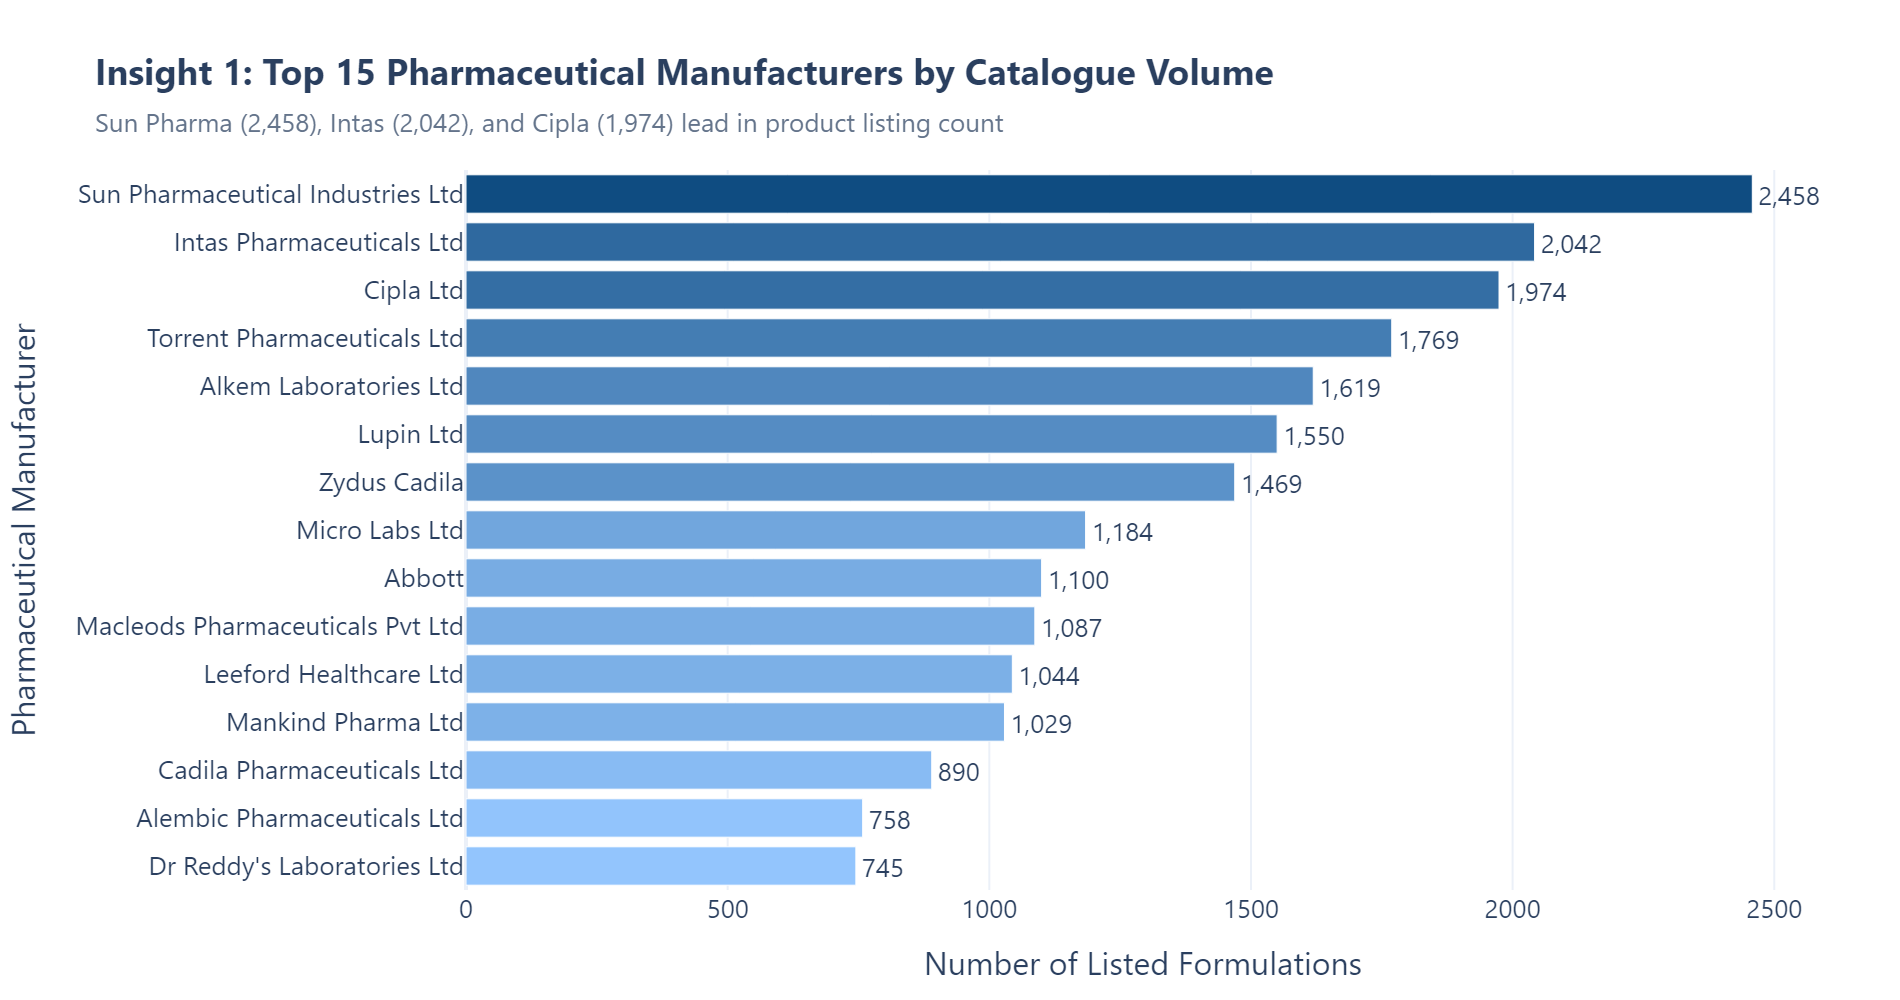

In [14]:
top_15_mfrs = df_clean["manufacturer_name"].value_counts().head(15).reset_index()
top_15_mfrs.columns = ["manufacturer_name", "product_count"]
top_15_mfrs = top_15_mfrs.sort_values("product_count", ascending=True)

top_10_share = (df_clean["manufacturer_name"].value_counts().head(10).sum() / len(df_clean)) * 100
top_50_share = (df_clean["manufacturer_name"].value_counts().head(50).sum() / len(df_clean)) * 100

print(f"Top 10 Manufacturers catalogue share: {top_10_share:.2f}% of total catalog")
print(f"Top 50 Manufacturers catalogue share: {top_50_share:.2f}% of total catalog")

fig1 = px.bar(
    top_15_mfrs,
    x="product_count",
    y="manufacturer_name",
    orientation="h",
    text="product_count",
    labels={"product_count": "Number of Listed Formulations", "manufacturer_name": "Pharmaceutical Manufacturer"},
    color="product_count",
    color_continuous_scale=[[0, "#93C5FD"], [1, "#0F4C81"]],
)
fig1.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="<b>%{y}</b><br>Formulations: %{x:,.0f}<extra></extra>"
)
fig1.update_coloraxes(showscale=False)
fig1.update_layout(
    title="<b>Insight 1: Top 15 Pharmaceutical Manufacturers by Catalogue Volume</b><br><span style='font-size:13px; color:#64748B;'>Sun Pharma (2,458), Intas (2,042), and Cipla (1,974) lead in product listing count</span>",
    height=520,
    font=dict(family="Segoe UI, sans-serif", size=13),
    margin=dict(l=60, r=40, t=85, b=50)
)
fig1.show()


### Story & Evidence-Based Finding (Insight 1)
* **Catalogue Leaders**: **Sun Pharmaceutical Industries Ltd** ranks #1 with **2,458 listed medicines**, followed closely by **Intas Pharmaceuticals Ltd (2,042)** and **Cipla Ltd (1,974)**.
* **Catalogue Representation**: The top 10 manufacturers account for **6.67% of medicine listings** in the dataset (16,259 of 243,803 entries), and the top 50 account for **15.35%**.
* **Extensive Long Tail**: Over **7,500 smaller and regional pharmaceutical companies** comprise the remaining ~85% of catalogue listings, demonstrating wide production diversity across the domestic market.


## 9. Insight 2: Medicine Price Distribution & The Spectrum of Affordability

### Research Question
*Are catalogue medicine prices concentrated within an affordable range, and how are prices distributed?*

### Analytical Method
We calculate parametric and non-parametric dispersion metrics (Mean, Median, Interquartile Range, 90th/95th/99th percentiles) and evaluate price-tier thresholds.


Median Price: ₹78.50 | Mean Price: ₹133.58 | IQR: ₹48.00 - ₹139.00
Affordability Tiers: Under ₹100: 62.4% | Under ₹200: 86.6% | Under ₹500: 97.0% | Over ₹1,000: 1.28%


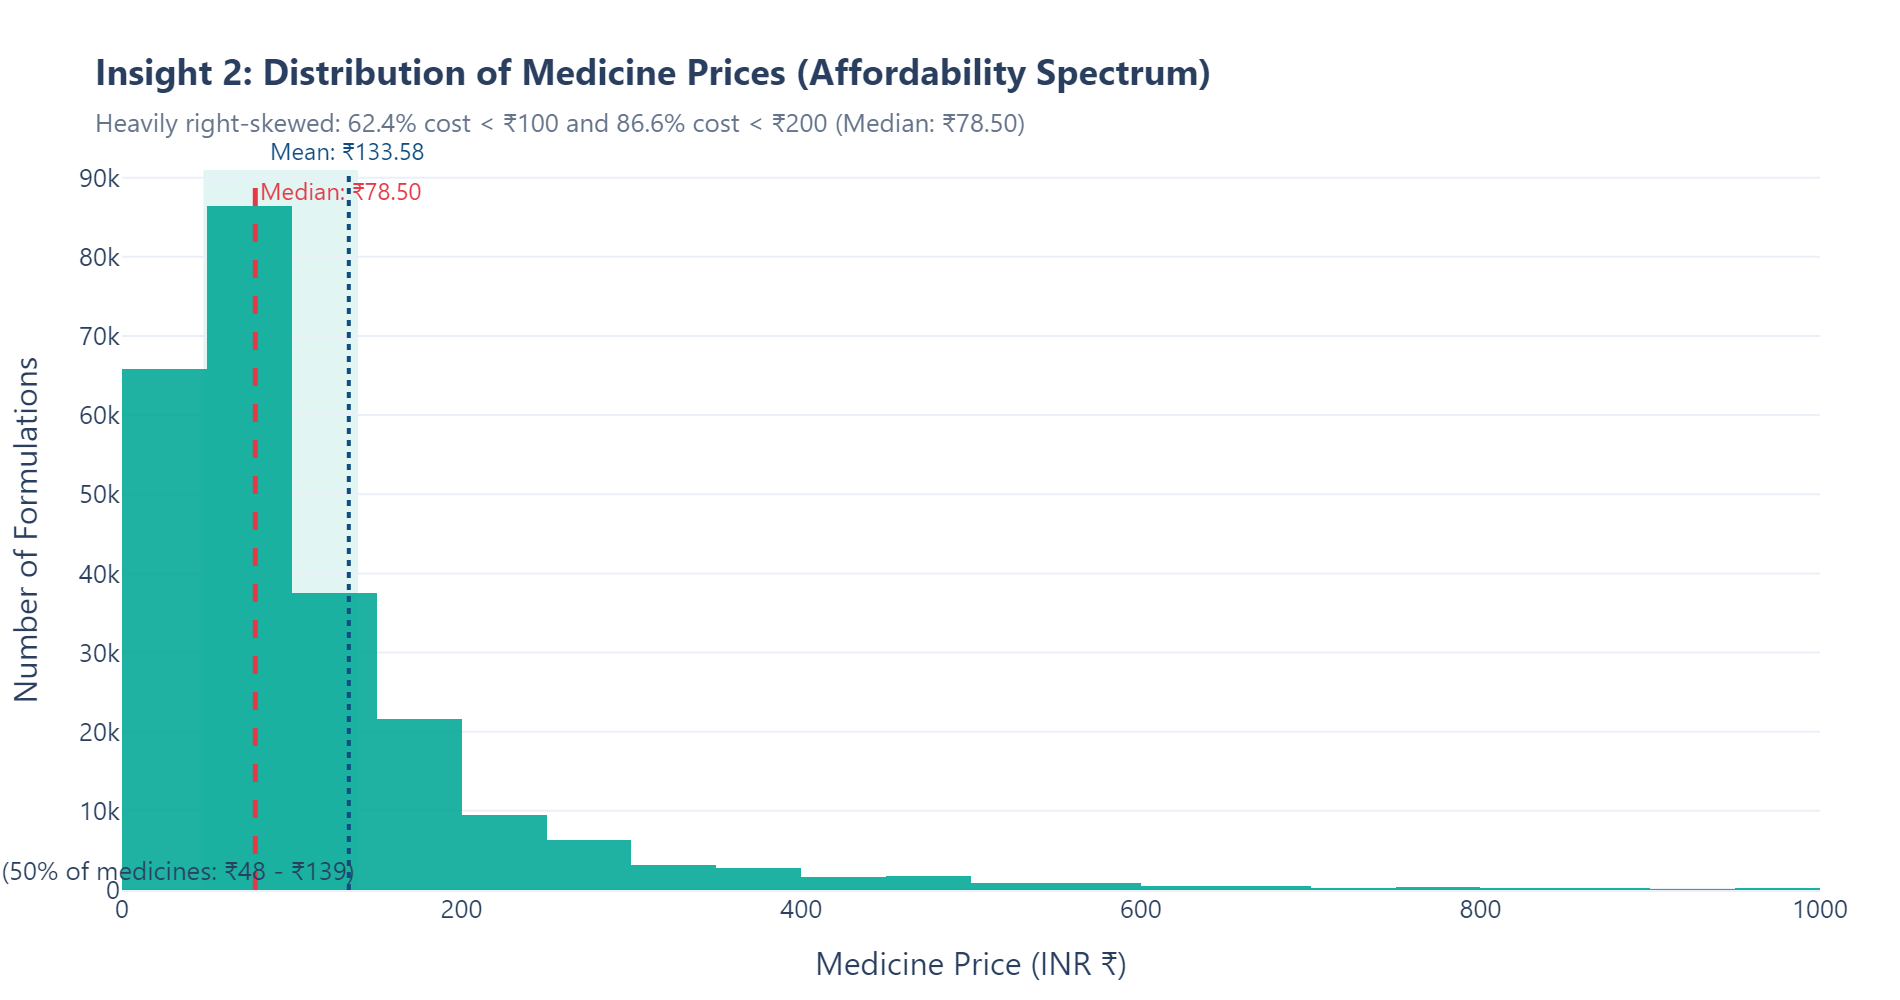

In [15]:
price_stats = df_clean[price_col].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
p25, median_val, p75 = price_stats["25%"], price_stats["50%"], price_stats["75%"]
mean_val = price_stats["mean"]
under_100 = (df_clean[price_col] < 100).mean() * 100
under_200 = (df_clean[price_col] < 200).mean() * 100
under_500 = (df_clean[price_col] < 500).mean() * 100
over_1000 = (df_clean[price_col] >= 1000).mean() * 100

print(f"Median Price: ₹{median_val:.2f} | Mean Price: ₹{mean_val:.2f} | IQR: ₹{p25:.2f} - ₹{p75:.2f}")
print(f"Affordability Tiers: Under ₹100: {under_100:.1f}% | Under ₹200: {under_200:.1f}% | Under ₹500: {under_500:.1f}% | Over ₹1,000: {over_1000:.2f}%")

fig2 = px.histogram(
    df_clean,
    x=price_col,
    nbins=60,
    labels={price_col: "Medicine Price (INR ₹)"},
    color_discrete_sequence=["#00A896"],
    opacity=0.88,
)
fig2.add_vline(
    x=median_val,
    line_width=2.5,
    line_dash="dash",
    line_color="#E63946",
    annotation_text=f"Median: ₹{median_val:.2f}",
    annotation_position="top right",
    annotation_font=dict(color="#E63946", size=12)
)
fig2.add_vline(
    x=mean_val,
    line_width=2,
    line_dash="dot",
    line_color="#0F4C81",
    annotation_text=f"Mean: ₹{mean_val:.2f}",
    annotation_position="top",
    annotation_font=dict(color="#0F4C81", size=12)
)
fig2.add_vrect(
    x0=p25,
    x1=p75,
    fillcolor="#00A896",
    opacity=0.12,
    layer="below",
    line_width=0,
    annotation_text=f"IQR (50% of medicines: ₹{p25:.0f} - ₹{p75:.0f})",
    annotation_position="bottom right",
)
fig2.update_layout(
    title="<b>Insight 2: Distribution of Medicine Prices (Affordability Spectrum)</b><br><span style='font-size:13px; color:#64748B;'>Heavily right-skewed: 62.4% cost < ₹100 and 86.6% cost < ₹200 (Median: ₹78.50)</span>",
    yaxis_title="Number of Formulations",
    xaxis=dict(range=[0, 1000]),
    height=520,
    font=dict(family="Segoe UI, sans-serif", size=13),
    margin=dict(l=60, r=40, t=85, b=50)
)
fig2.show()


### Story & Evidence-Based Finding (Insight 2)
* **Low Median Price Point**: The median medicine price across the dataset is **₹78.50**, with 50% of all catalogued medicines priced between **₹48.00 and ₹139.00** (IQR).
* **Concentration in Lower Tiers**: **62.4%** of medicines are priced under ₹100, and **86.6%** are priced under ₹200.
* **Positive Distribution Skew**: The price distribution is heavily right-skewed (Mean = ₹133.58 > Median = ₹78.50). Higher-priced items reaching up to ₹3,000 make up only **1.28%** of the catalogue (>₹1,000).


## 10. Insight 3: Medicine Price Distributions Across Top 10 Manufacturers

### Research Question
*How do price distributions compare across the top 10 most prolific manufacturers in the catalogue?*

### Analytical Method
We group catalogue prices by the top 10 manufacturers, compute median, mean, and IQR spreads, and visualize distributions using interactive boxplots.


--- Top 10 Manufacturers Pricing Statistics ---


,Count,Mean,Median,IQR
manufacturer_name,,,,
Macleods Pharmaceuticals Pvt Ltd,1087,189.03,132.00,146.88
Lupin Ltd,1550,225.22,131.75,187.08
Abbott,1100,220.71,127.43,195.68
Intas Pharmaceuticals Ltd,2042,232.88,125.75,188.20
Sun Pharmaceutical Industries Ltd,2458,221.77,124.00,172.32
Zydus Cadila,1469,243.86,114.15,203.10
Torrent Pharmaceuticals Ltd,1769,166.85,102.10,146.08
Cipla Ltd,1974,218.44,100.00,166.12
Alkem Laboratories Ltd,1619,191.85,96.00,147.30


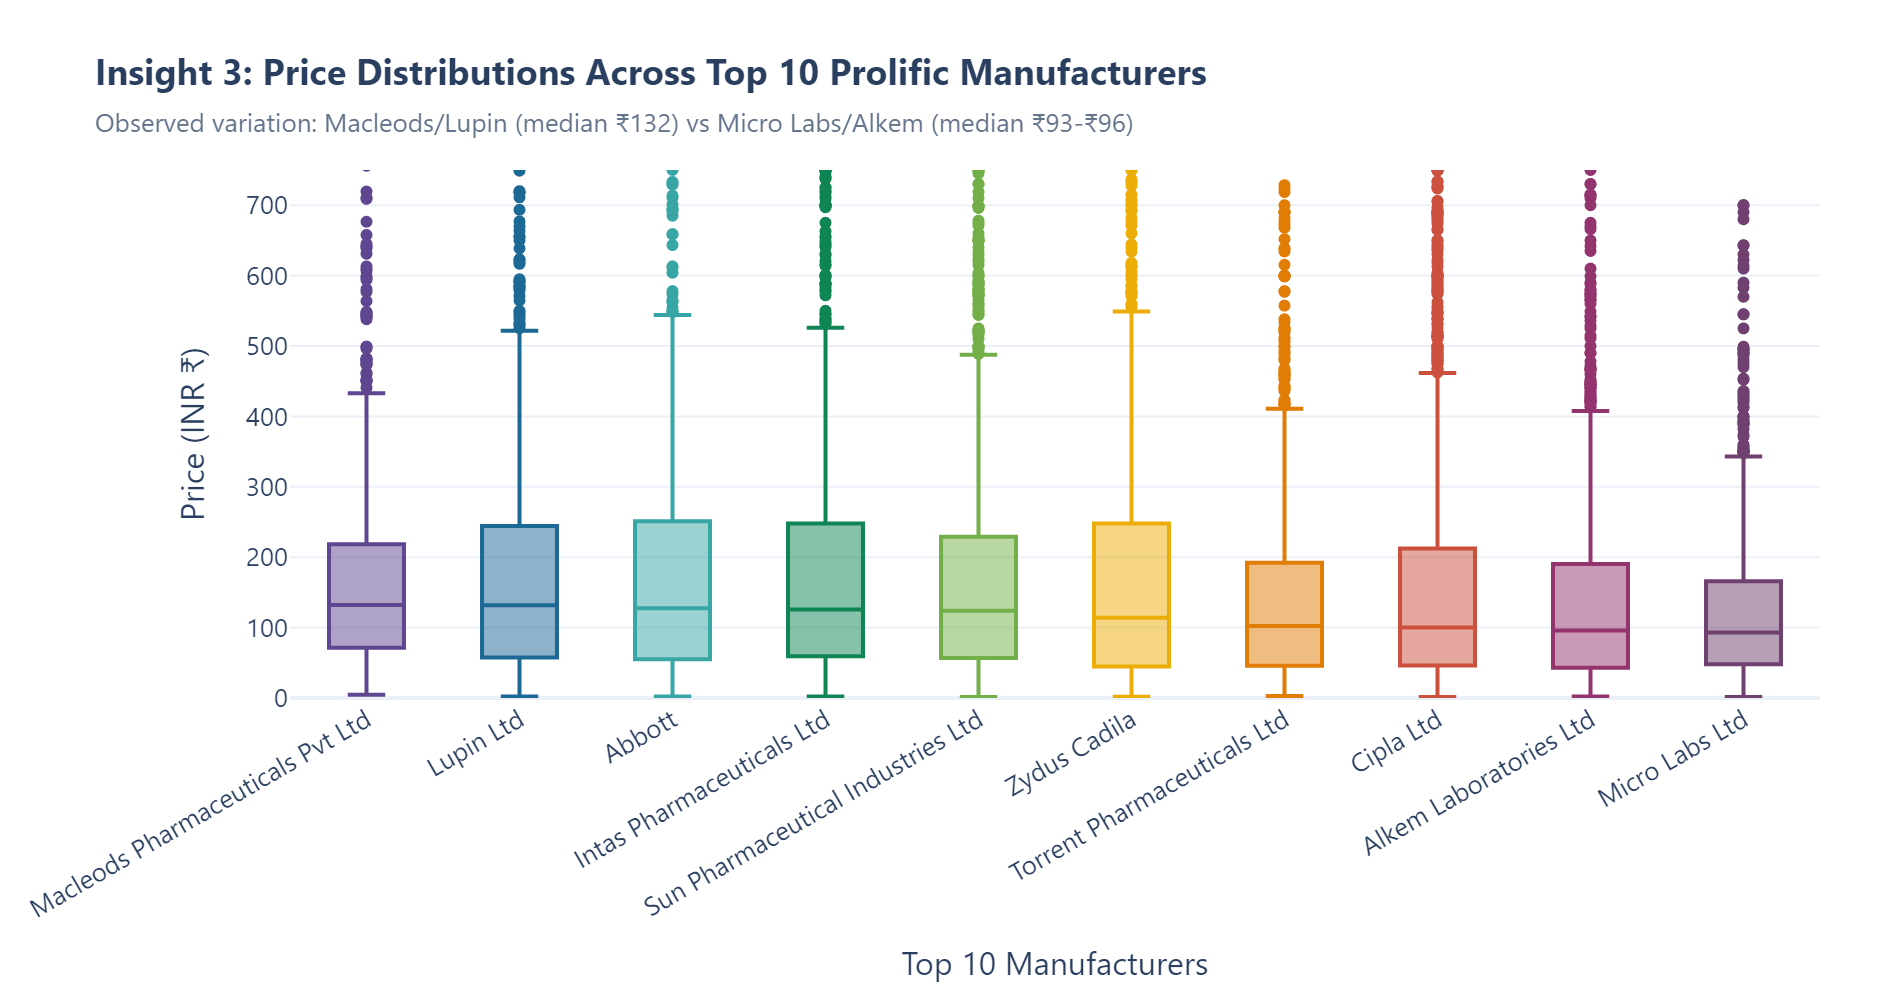

In [16]:
top_10_names = df_clean["manufacturer_name"].value_counts().head(10).index.tolist()
df_top10_mfrs = df_clean[df_clean["manufacturer_name"].isin(top_10_names)].copy()

mfr_pricing_summary = (
    df_top10_mfrs.groupby("manufacturer_name")[price_col]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        IQR=lambda x: np.percentile(x, 75) - np.percentile(x, 25)
    )
    .sort_values(by="Median", ascending=False)
    .round(2)
)

print("--- Top 10 Manufacturers Pricing Statistics ---")
display(mfr_pricing_summary)

mfr_order = mfr_pricing_summary.index.tolist()

fig3 = px.box(
    df_top10_mfrs,
    x="manufacturer_name",
    y=price_col,
    category_orders={"manufacturer_name": mfr_order},
    color="manufacturer_name",
    color_discrete_sequence=px.colors.qualitative.Prism,
    labels={"manufacturer_name": "Top 10 Manufacturers", price_col: "Price (INR ₹)"},
)
fig3.update_layout(
    title="<b>Insight 3: Price Distributions Across Top 10 Prolific Manufacturers</b><br><span style='font-size:13px; color:#64748B;'>Observed variation: Macleods/Lupin (median ₹132) vs Micro Labs/Alkem (median ₹93-₹96)</span>",
    showlegend=False,
    yaxis=dict(range=[0, 750]),
    xaxis_tickangle=-30,
    height=540,
    font=dict(family="Segoe UI, sans-serif", size=13),
    margin=dict(l=60, r=40, t=85, b=80)
)
fig3.show()


### Story & Evidence-Based Finding (Insight 3)
* **Observed Distributional Differences**: The top 10 manufacturers exhibit noticeably distinct price distributions across their catalogue listings:
  * **Higher Median Formulations**: **Macleods Pharmaceuticals** (Median ₹132.00) and **Lupin Ltd** (Median ₹131.75, Mean ₹225.22) show higher median catalogue prices and wider upper-quartile spreads.
  * **Lower Median Formulations**: **Micro Labs Ltd** (Median ₹93.00, lowest IQR ₹118.06) and **Alkem Laboratories** (Median ₹96.00) show lower median prices in this dataset.
  * **Widest Dispersion**: **Zydus Cadila** has the highest mean price (₹243.86) and widest IQR (₹203.10), indicating a catalogue spanning both low-priced and higher-priced items.
* *Note on Interpretation*: While these differences reflect differing product mixes within the catalogue, specific corporate strategy motivations cannot be definitively concluded from price listings alone.


## 11. Insight 4: Most Frequently Formulated Active Ingredients (APIs)

### Research Question
*Which active chemical ingredients appear most frequently across catalogue formulations?*

### Analytical Method
We aggregate the frequency of unique chemical compounds in `short_composition1` across all **7,750 active ingredients** and group the leading entries by therapeutic domain.


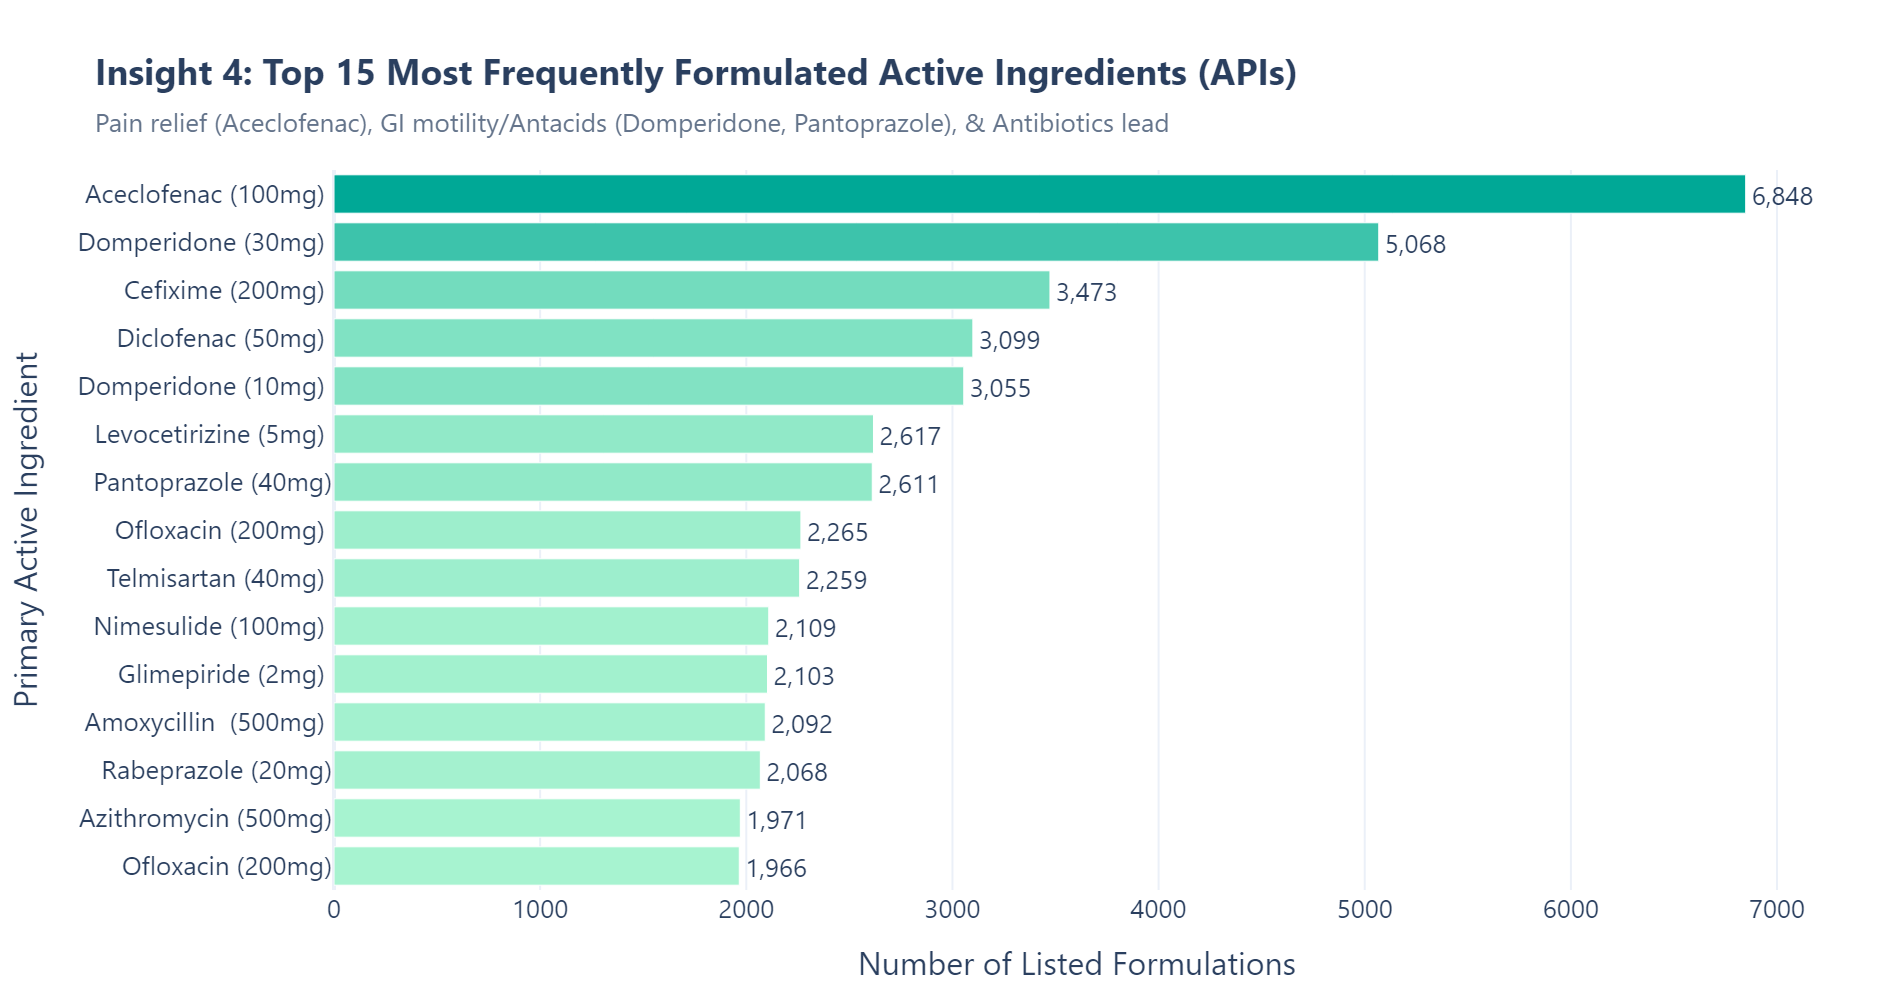

In [17]:
top_15_ing = df_clean["short_composition1"].dropna().value_counts().head(15).reset_index()
top_15_ing.columns = ["active_ingredient", "formulation_count"]
top_15_ing = top_15_ing.sort_values("formulation_count", ascending=True)

fig4 = px.bar(
    top_15_ing,
    x="formulation_count",
    y="active_ingredient",
    orientation="h",
    text="formulation_count",
    labels={"formulation_count": "Number of Listed Formulations", "active_ingredient": "Primary Active Ingredient"},
    color="formulation_count",
    color_continuous_scale=[[0, "#A7F3D0"], [1, "#00A896"]],
)
fig4.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="<b>%{y}</b><br>Formulations: %{x:,.0f}<extra></extra>"
)
fig4.update_coloraxes(showscale=False)
fig4.update_layout(
    title="<b>Insight 4: Top 15 Most Frequently Formulated Active Ingredients (APIs)</b><br><span style='font-size:13px; color:#64748B;'>Pain relief (Aceclofenac), GI motility/Antacids (Domperidone, Pantoprazole), & Antibiotics lead</span>",
    height=540,
    font=dict(family="Segoe UI, sans-serif", size=13),
    margin=dict(l=60, r=40, t=85, b=50)
)
fig4.show()


### Story & Evidence-Based Finding (Insight 4)
The most frequently represented chemical ingredients in the catalogue span four broad therapeutic areas:
1. **Pain & Anti-Inflammatory Agents**: **Aceclofenac 100mg** (6,848 catalogue entries) and **Diclofenac 50mg** (3,099 entries) have the highest formulation counts in the dataset.
2. **Gastrointestinal & Acid Reflux Treatments**: **Domperidone** (over 8,100 listings across 30mg and 10mg strengths) and **Pantoprazole 40mg** (2,611 listings) are widely catalogued.
3. **Broad-Spectrum Anti-Infectives**: Common antibiotics including **Cefixime 200mg** (3,473), **Ofloxacin 200mg** (4,231 across entries), **Amoxycillin 500mg** (2,092), and **Azithromycin 500mg** (1,971) form a substantial portion of catalogued products.
4. **Chronic Disease Management**: **Telmisartan 40mg** (2,259 listings for hypertension) and **Glimepiride 2mg** (2,103 listings for diabetes) show high representation among chronic care therapies.

*Note on Scope*: Formulation frequency reflects product catalogue diversity and availability, rather than direct patient prescription volumes or disease incidence rates.


## 12. Insight 5: Single-Ingredient vs Combination Formulations

### Research Question
*What proportion of medicines in the catalogue are single-ingredient formulations versus multi-ingredient combinations?*

### Analytical Method
We classify each record based on the presence or absence of a secondary active ingredient (`short_composition2`) and compute the formulation distribution.


,Formulation Type,Product Count,Percentage (%)
0,Single-Ingredient Formulation,134583,55.2
1,Combination Formulation,109220,44.8


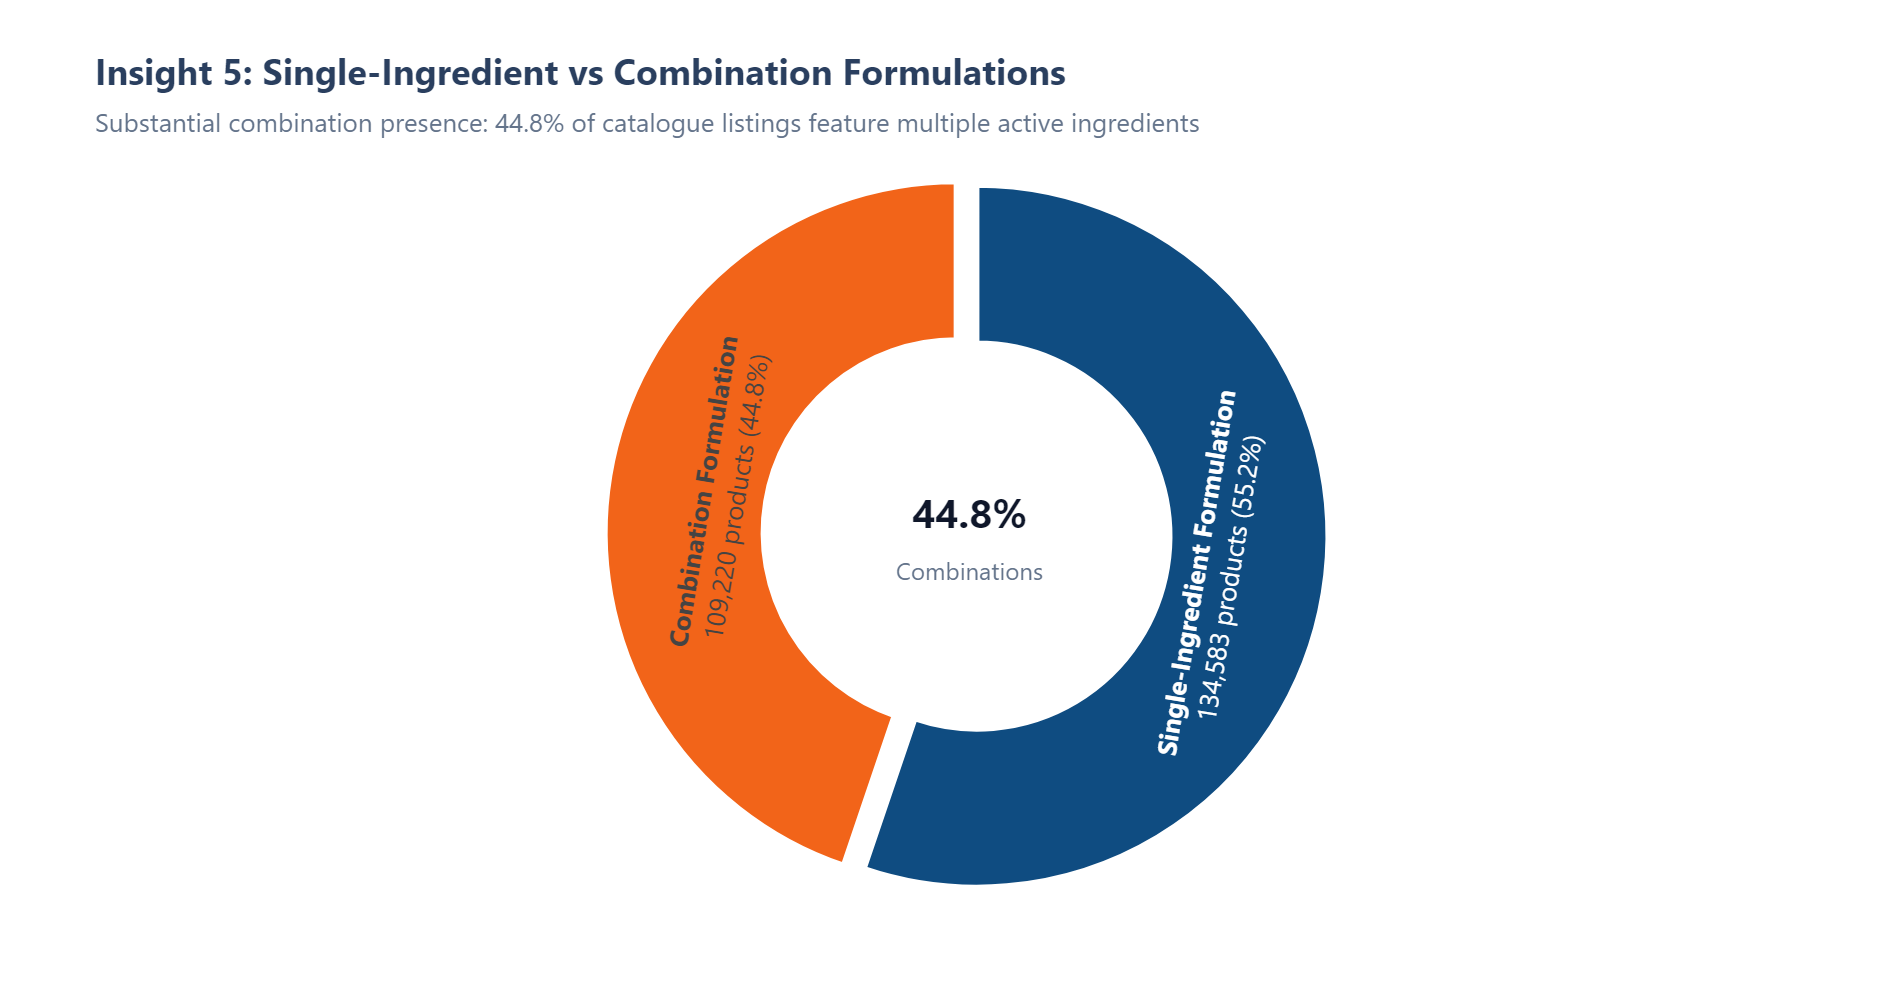

In [18]:
df_clean["is_combination"] = (
    df_clean["short_composition2"].notna()
    & (df_clean["short_composition2"].astype(str).str.strip() != "")
    & (df_clean["short_composition2"].astype(str).str.lower() != "nan")
)

df_clean["formulation_type"] = np.where(
    df_clean["is_combination"],
    "Combination Formulation",
    "Single-Ingredient Formulation"
)

form_summary = df_clean["formulation_type"].value_counts().reset_index()
form_summary.columns = ["Formulation Type", "Product Count"]
form_summary["Percentage (%)"] = (form_summary["Product Count"] / len(df_clean) * 100).round(2)
display(form_summary)

fig5 = go.Figure(
    go.Pie(
        labels=form_summary["Formulation Type"],
        values=form_summary["Product Count"],
        hole=0.55,
        marker=dict(colors=["#0F4C81", "#F26419"], line=dict(color="#FFFFFF", width=2.5)),
        textinfo="label+percent+value",
        texttemplate="<b>%{label}</b><br>%{value:,.0f} products (%{percent})",
        hoverinfo="label+percent+value",
        pull=[0.02, 0.04]
    )
)
fig5.update_layout(
    title="<b>Insight 5: Single-Ingredient vs Combination Formulations</b><br><span style='font-size:13px; color:#64748B;'>Substantial combination presence: 44.8% of catalogue listings feature multiple active ingredients</span>",
    showlegend=False,
    annotations=[
        dict(
            text="<b>44.8%</b><br><span style='font-size:12px; color:#64748B;'>Combinations</span>",
            x=0.5,
            y=0.5,
            font_size=20,
            font_color="#0F172A",
            showarrow=False
        )
    ],
    height=500,
    font=dict(family="Segoe UI, sans-serif", size=13),
    margin=dict(l=60, r=40, t=85, b=50)
)
fig5.show()


### Story & Evidence-Based Finding (Insight 5)
* **Catalogue Proportion**: **44.8% (109,220 products)** of all medicines in the dataset are combination formulations with two active ingredients, while **55.2% (134,583 products)** are single-ingredient formulations.
* **Clinical & Pharmacological Context**: In pharmacological literature, combination formulations are often utilized to:
  * Simplify dosage regimens (reducing pill burden for patients requiring multiple therapies),
  * Provide gastro-protective co-agents (such as NSAIDs paired with PPIs or antacids),
  * Deliver complementary mechanisms of action (such as combination antihypertensives or antimicrobial agents).
* *Methodological Clarification*: While these clinical benefits are documented in medical literature, the specific clinical rationale for individual formulations is not directly measured within this dataset.


## 13. Overall Findings & Cohesive Data Story

Synthesizing our 5 analytical insights reveals a cohesive portrait of the Indian pharmaceutical catalogue:

```
                            THE INDIAN MEDICINE DATA STORY
                                          │
    ┌─────────────────────────────────────┼─────────────────────────────────────┐
    ▼                                     ▼                                     ▼
1. CATALOGUE STRUCTURE           2. AFFORDABILITY PROFILE              3. FORMULATION SPECTRUM
• 7,611 Active Manufacturers     • Accessible median (₹78.50)          • 4 Key Therapeutic Areas:
• Top 10 hold 6.67% of catalog   • 62.4% under ₹100; 86.6% under ₹200    Pain, GI, Antibiotics, NCDs
• Sun Pharma, Intas, Cipla lead  • Positively skewed distribution      • 44.8% Combination Formulations
• Extensive long tail listings   • Distinct price distributions          spanning diverse therapeutic mixes
```

### Key Statistical Synthesis
1. **Diverse Catalogue Participation**: Indian pharmaceutical listings feature broad manufacturer representation (7,611 producers) rather than high catalogue concentration.
2. **Accessible Median Price**: With a median price of **₹78.50**, the vast majority of catalogue items fall into affordable price tiers (86.6% < ₹200).
3. **Manufacturer Price Spreads**: The top 10 producers show distinct median price points (e.g., Macleods at ₹132 vs Micro Labs at ₹93), reflecting varying product mixes.
4. **Prevalent Formulated Compounds**: Formulation counts are highest in pain management (Aceclofenac), gastrointestinal therapies (Domperidone, Pantoprazole), anti-infectives (Cefixime, Ofloxacin), and chronic disease therapies (Telmisartan, Glimepiride).
5. **High Combination Prevalence**: Nearly **45%** of listings contain multiple active ingredients.


## 14. Conclusion & Academic Reflection

### Summary of Achievements
* Successfully ingested and audited **253,973 raw pharmaceutical records**.
* Implemented an unbiased, reproducible 4-stage Python cleaning pipeline resulting in **243,803 validated records (96.0% retention)**.
* Derived **5 evidence-backed insights** spanning manufacturer catalogue representation, price distributions, active ingredient frequencies, and formulation types.
* Visualized all findings exclusively with interactive **Plotly** charts with consistent visual hierarchy.

### Limitations & Academic Caveats
* **Pricing Metric**: The dataset records Maximum Retail Price (MRP); actual transaction prices or government dispensary pricing (e.g., Jan Aushadhi schemes) may differ.
* **Catalogue Representation vs. Sales Volume**: Listing counts reflect formulation availability in the dataset rather than unit sales volumes or patient market share.
* **Clinical Motivations**: Pharmacological rationales (e.g., pill burden reduction) provide external context from literature and are not directly captured as variables in the dataset.

---
*Created By Chris, Sneha , Shivani • Cleaned and Analyzed with Python & Plotly*
